# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Sienna Joya Haag
* Username: sjhaag
* Student number: S6214320
* Group (AS1, etc.): AS1

-----

In [ ]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

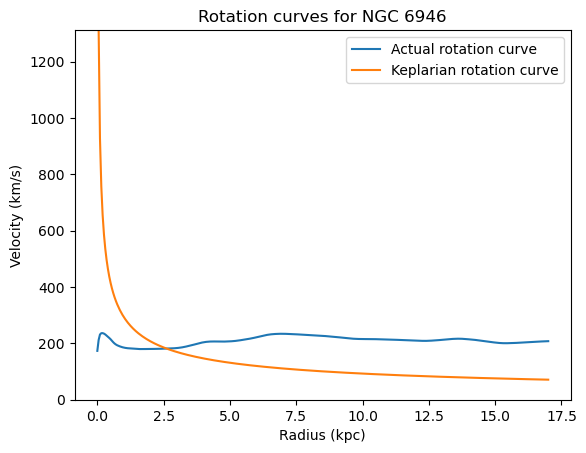

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G
from astropy.constants import M_sun

mSun = M_sun.value
f = open('rotcur.dat.txt', 'r')
radius, rvel = np.loadtxt(f, comments = '#', unpack = True, usecols = (0,1))
plt.figure()
plt.plot(radius, rvel, label = "Actual rotation curve")

ri = np.where(radius>0) # Mask to avoid division by zero error
rm = radius[ri]*3.086e+19 # Converting to metres
v = np.sqrt(G*2*10**10*mSun/rm)/1000 # In km/s
K = np.vstack( (radius[ri], v) ).T # Saves radius in kpc!! and v in km/s
f2 = open('keplerian_curve.txt', 'w')
np.savetxt('keplerian_curve.txt', K)

radius1, kvel = np.loadtxt('keplerian_curve.txt', unpack=True)
plt.plot(radius1, kvel, label = "Keplarian rotation curve")
plt.ylim((0,kvel.max()))
plt.ylabel("Velocity (km/s)")
plt.xlabel("Radius (kpc)")
plt.legend()
plt.title("Rotation curves for NGC 6946")
plt.show()
f.close()
f2.close()

As expected, the actual observed rotation velocities are different to those predicted by the keplerian model. This is one of the strongest points of evidence for dark matter, especially the fact that the rotation velocties remain relatively constant even at greater values of radii.

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

The mean is -0.024 as expected! (close to 0)
The standard deviation is 1.013 as expected! (close to 1)


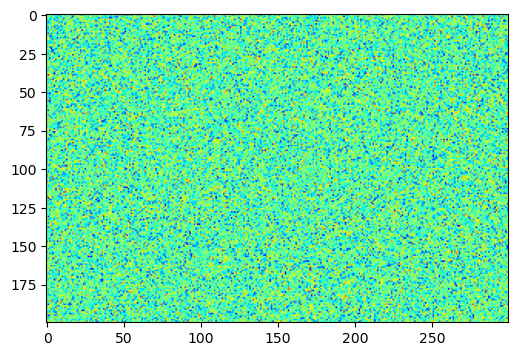

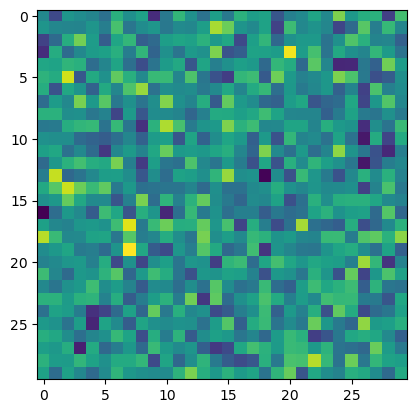

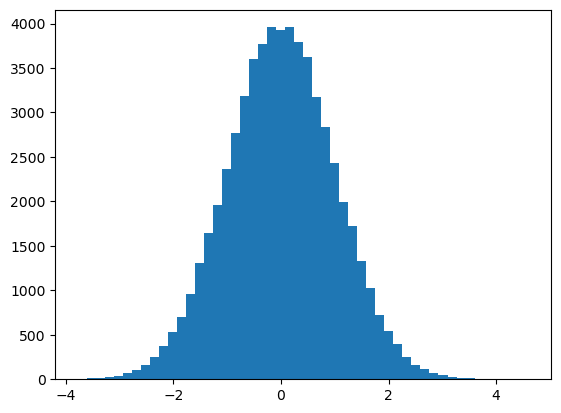

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show

m = np.random.normal(size = (200,300))
plt.figure(figsize=(8, 4)) 
plt.imshow(m, cmap ='jet')

# Randomly choosing 30 x 30 pixel area
x30 = np.random.randint(0, 170)
y30 = np.random.randint(0, 270)
m30 = m[x30:x30+30,y30:y30+30]

plt.figure()
plt.imshow(m30)
print(f"The mean is {round(m30.mean(), 3)} as expected! (close to 0)")
print(f"The standard deviation is {round(np.std(m30), 3)} as expected! (close to 1)")
plt.figure()
plt.hist(m.flatten(), bins = 50)
plt.show()

As expected, we can recognise a normal distribution shape with mean 0 and standard deviation 1.


In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

The area of this ellispe is 18.85
The perimeter of this ellispe is 15.865
This ellipse has center (1, 2), axes 3.0 and 2.0, and angle 0.


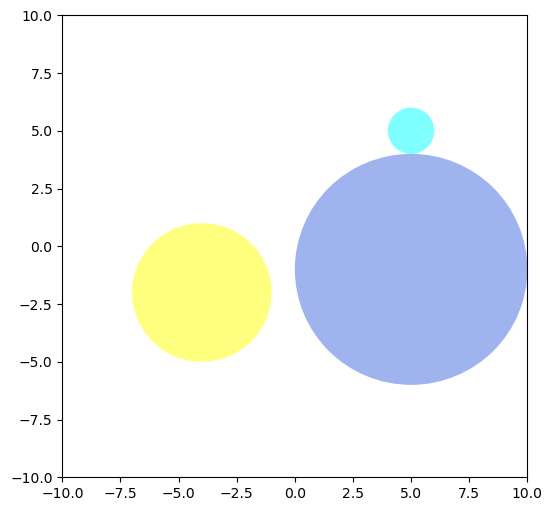

In [15]:
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib.pyplot as plt

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)

    def Area(self):
        area = (self.height/2)*(self.width/2)*np.pi
        return area

    def Perimeter(self):
        a = self.height/2
        b = self.width/2
        h = ((a-b)**2)/((a+b)**2)
        p = np.pi*(a+b)*(1+(3*h)/(10 + np.sqrt(4-3*h)))
        return p

    def ___str___(self):
        return f"This ellipse has center {self.center}, axes {self.height/2} and {self.width/2}, and angle {self.angle}."
        
A = AstroEllipse(1,2,3,2,0)
print(f"The area of this ellispe is {round(A.Area(), 3)}")
print(f"The perimeter of this ellispe is {round(A.Perimeter(), 3)}")
print(A.___str___())

class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius):#
        xc = xc
        yc = yc
        angle = 0
        sma = radius
        smi = radius
        super().__init__(xc, yc, sma, smi, angle)

fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
# Random center and radius values (so circle is within limits of plot)
c1 = MyCircle(np.random.randint(-5,6), np.random.randint(-5,6), np.random.randint(1,6))
c2 = MyCircle(np.random.randint(-5,6), np.random.randint(-5,6), np.random.randint(1,6))
c3 = MyCircle(np.random.randint(-5,6), np.random.randint(-5,6), np.random.randint(1,6))
ax.add_patch(c1)
ax.add_patch(c2)
ax.add_patch(c3)
c1.set_alpha(0.5) 
c2.set_alpha(0.5) 
c3.set_alpha(0.5) 
c1.set_facecolor('yellow')
c2.set_facecolor('royalblue')
c3.set_facecolor('cyan')
plt.show()


In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

x = np.linspace(0, 10, 1000)
one = jv(1,x)
two = jv(2,x)
three = jv(3,x)
four = jv(4,x)
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(x, one, label = "First order", color = 'r')
axs[0,1].plot(x, two, label = "Second order", color = 'b')
axs[1,0].plot(x, three, label = "Third order", color = 'y')
axs[1,1].plot(x, four, label = "Fourth order", color = 'purple')

fig.suptitle("Bessel Functions of the first, second, third, and fourth order")
fig.supylabel("Bessel Function")
fig.supxlabel("X")

fig.legend()
fig.show()
fig.savefig("bessel", transparent = True)

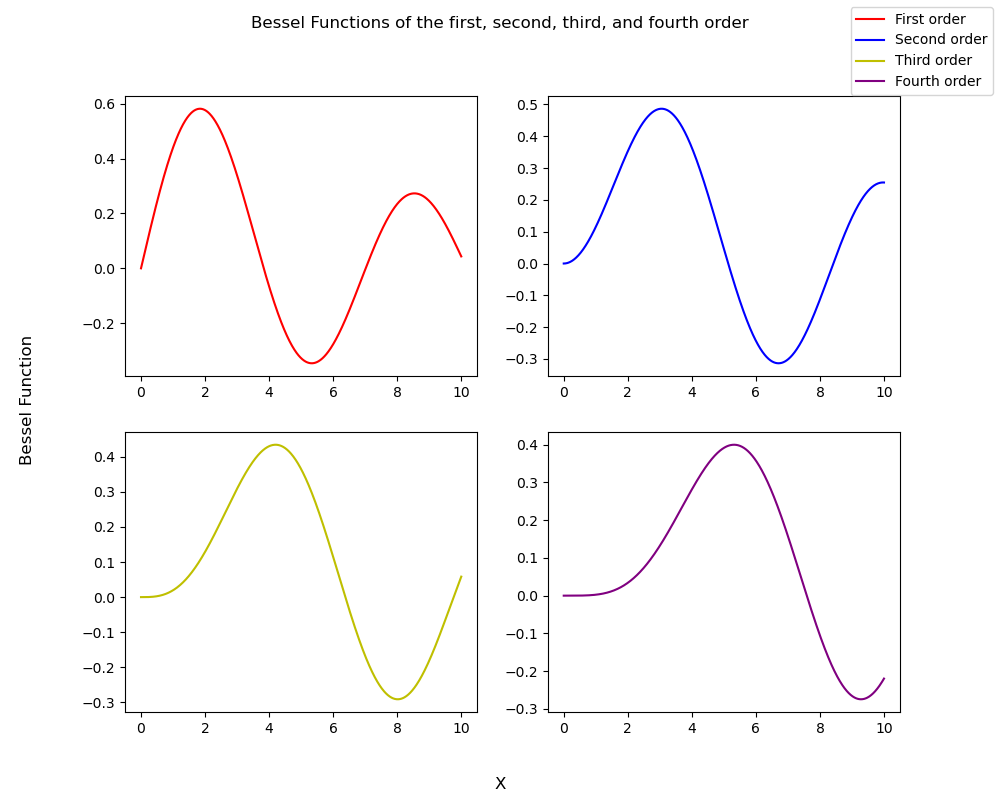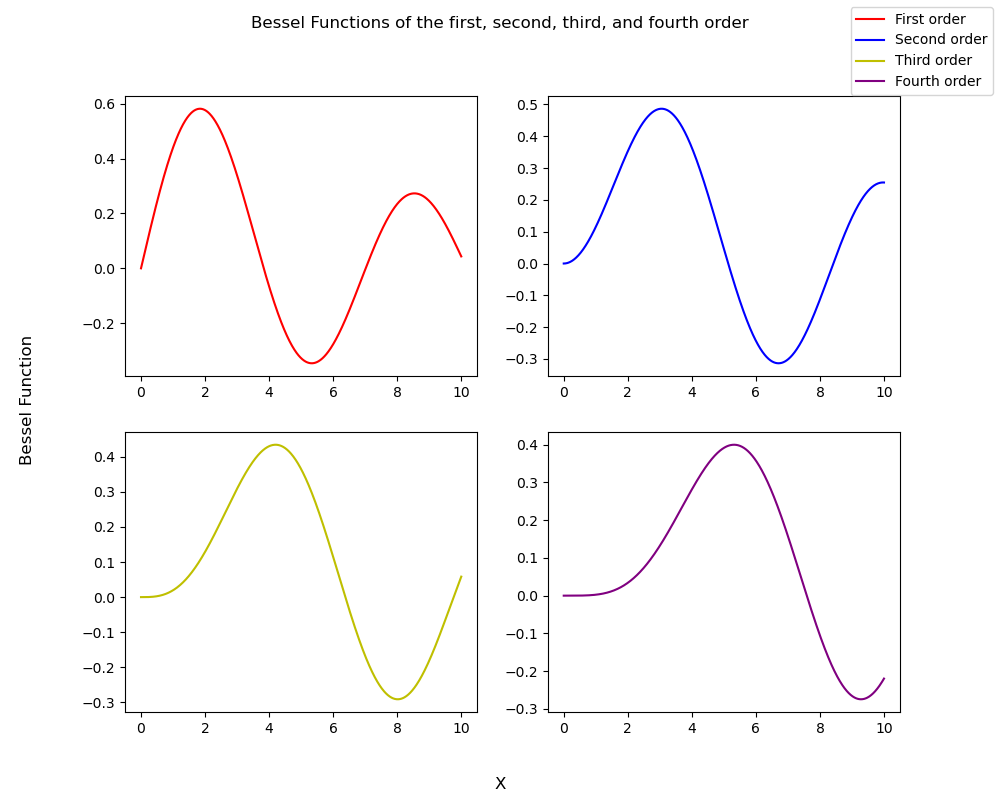

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

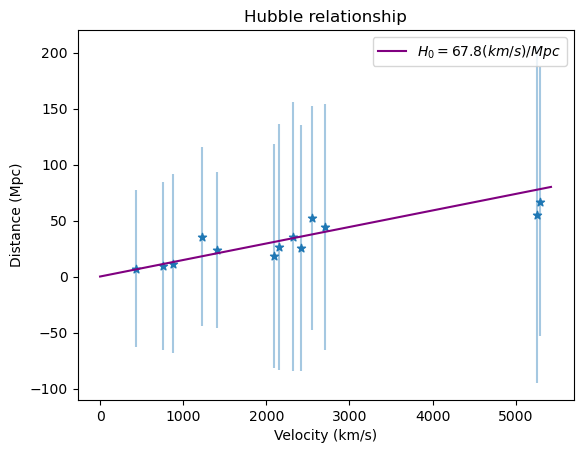

In [21]:
import numpy as np
import matplotlib.pyplot as plt

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]

D = data[0:len(data):4]
V = data[1:len(data):4]
deltaD = data[2:len(data):4]
deltaV = data[3:len(data):4]
fig, ax = plt.subplots()
ax.scatter(V, D, marker='*')
ax.errorbar(V, D, yerr=deltaV, xerr=deltaD, fmt='none', alpha = 0.4)

y = np.linspace(0,80,500)
x = y*67.8
ax.plot(x, y, label=r"$H_0 = 67.8 (km/s)/Mpc$", color = 'purple')
ax.set_ylabel("Distance (Mpc)")
ax.set_xlabel("Velocity (km/s)")
ax.set_title("Hubble relationship")
ax.legend()

fig.show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")